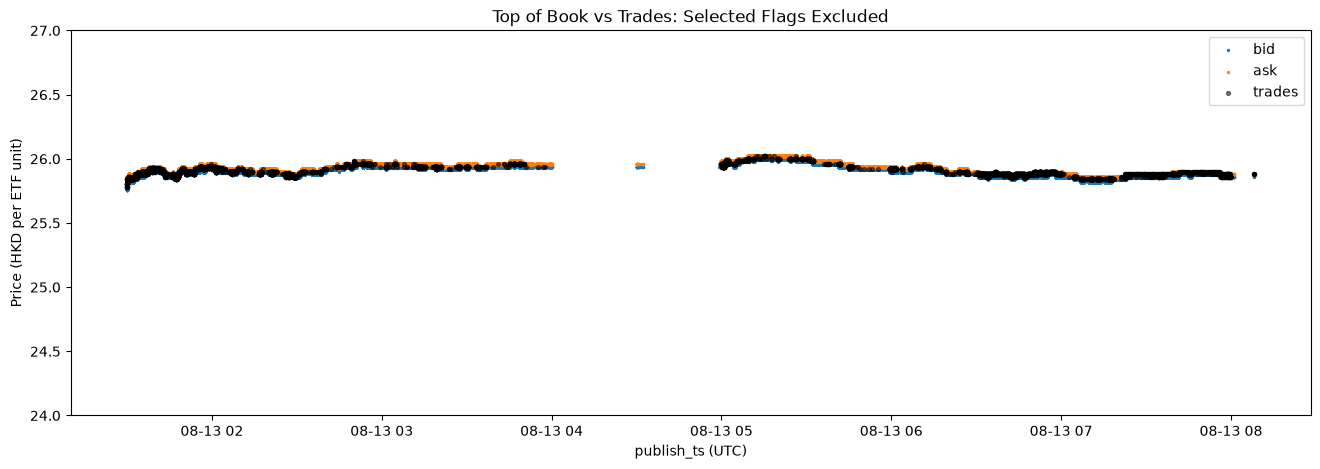

In [3]:
import polars as pl
import matplotlib.pyplot as plt

top = pl.read_parquet("../parquets/A_topofbook_flagged.parquet")
trades = pl.read_parquet("../parquets/A_trades_flagged.parquet")

top_flags = [
    "crossed_book", "locked_book", "spread_outlier", "latency_gt_p99",
    "latency_gt_1s", "large_time_gap", "repeated_quote", "transient_quote_candidate",
]
trade_flags = ["latency_gt_p99", "latency_gt_1s", "trade_price_candidate"]

top = top.with_columns(
    selected_quote_flag=(pl.col("quote_state") != "two_sided") | pl.any_horizontal(top_flags).fill_null(False)
)
trades = trades.with_columns(
    selected_trade_flag=pl.any_horizontal(trade_flags).fill_null(False)
)

trade_top = trades.sort(["publish_ts", "ingress_ts", "trade_id_num"]).join_asof(
    top.rename(lambda c: c if c == "instrument" else f"top_{c}").sort(["top_publish_ts", "top_seq_id"]),
    left_on="publish_ts", right_on="top_publish_ts", by="instrument",
    strategy="backward", check_sortedness=False,
)

trade_top = trade_top.with_columns(
    no_prior_bbo=pl.col("top_publish_ts").is_null(),
    quote_age_us=(pl.col("publish_ts") - pl.col("top_publish_ts")).dt.total_microseconds(),
    quote_captured_after_trade=pl.col("top_ingress_ts") > pl.col("ingress_ts"),
    trade_below_bid=pl.col("price") < pl.col("top_bid_price"),
    trade_above_ask=pl.col("price") > pl.col("top_ask_price"),
    trade_inside_bbo=(pl.col("price") >= pl.col("top_bid_price")) & (pl.col("price") <= pl.col("top_ask_price")),
).with_columns(
    matched_abnormal_bbo=pl.col("top_selected_quote_flag"),
    trade_outside_bbo=pl.col("trade_below_bid") | pl.col("trade_above_ask"),
).with_columns(
    cross_file_anomaly=pl.any_horizontal("no_prior_bbo", "matched_abnormal_bbo", "trade_outside_bbo").fill_null(False)
)

top_clean = top.filter(~pl.col("selected_quote_flag"))
trade_clean = trade_top.filter(~pl.col("selected_trade_flag") & ~pl.col("cross_file_anomaly"))

plt.figure(figsize=(16, 5))
plt.scatter(top_clean["publish_ts"], top_clean["bid_price"], s=2, label="bid")
plt.scatter(top_clean["publish_ts"], top_clean["ask_price"], s=2, label="ask")
plt.scatter(trade_clean["publish_ts"], trade_clean["price"], s=8, color="black", alpha=0.5, label="trades")
plt.ylim(24, 27)
plt.title("Top of Book vs Trades: Selected Flags Excluded")
plt.xlabel("publish_ts (UTC)")
plt.ylabel("Price (HKD per ETF unit)")
plt.legend()
plt.show()